In [1]:
import pandas as pd

# Load full quantum features
df = pd.read_csv("../quantum_raw_parkinsons_gait_percent.csv")

print(f"✅ Loaded full quantum features: {df.shape[1]} columns.")

✅ Loaded full quantum features: 12 columns.


In [2]:
import matplotlib.pyplot as plt

def plot_history(history, title):
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    # Accuracy Plot
    axs[0].plot(history.history['accuracy'], label="Train Accuracy")
    axs[0].plot(history.history['val_accuracy'], label="Validation Accuracy")
    axs[0].set_title(f"Model Accuracy - {title}")
    axs[0].set_xlabel("Epochs")
    axs[0].set_ylabel("Accuracy")
    axs[0].legend()

    # Loss Plot
    axs[1].plot(history.history['loss'], label="Train Loss")
    axs[1].plot(history.history['val_loss'], label="Validation Loss")
    axs[1].set_title(f"Model Loss - {title}")
    axs[1].set_xlabel("Epochs")
    axs[1].set_ylabel("Loss")
    axs[1].legend()

    plt.show()

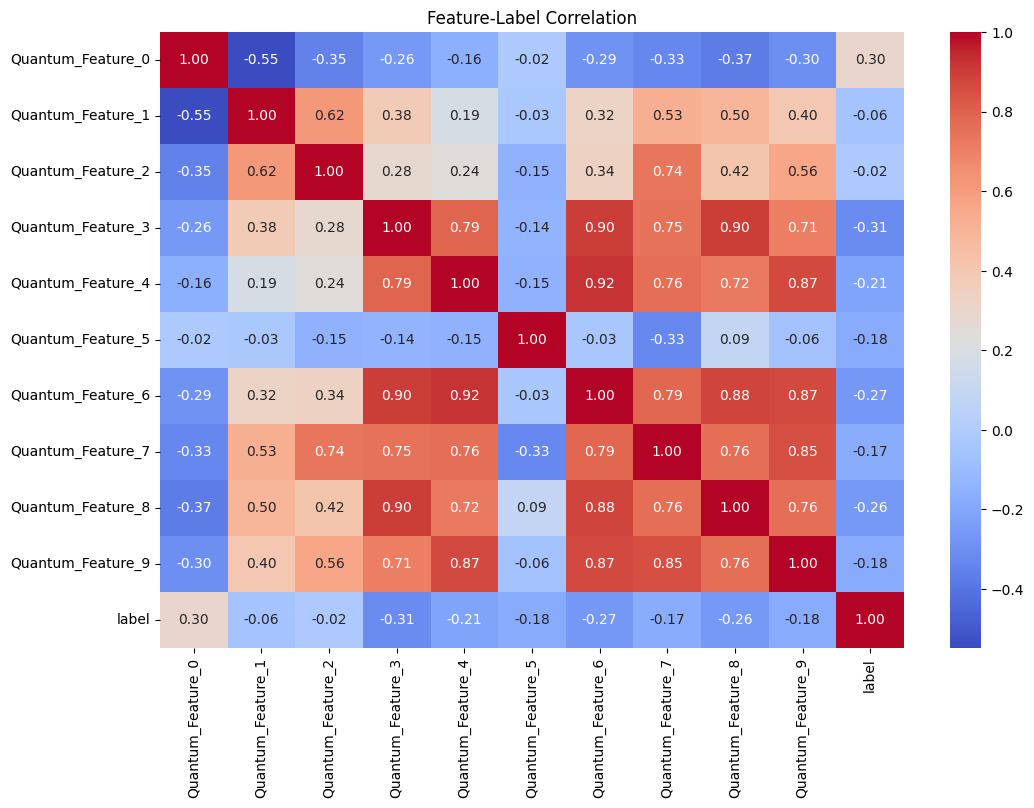

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

df = df.drop(columns=["Subject_ID"])
df_corr = df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(df_corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature-Label Correlation")
plt.show()

In [4]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.layers import BatchNormalization, Dropout

tf.keras.backend.set_floatx('float32')

# Ensure features and labels are correctly extracted
X = df.drop(columns=["label"]).values  # Features
y = df["label"].values  # Labels

# Convert labels to one-hot encoding *before* splitting
y_onehot = tf.keras.utils.to_categorical(y, num_classes=2)

# Split once: train + temp
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, stratify=y_onehot, random_state=42)

# Split again: train + val (from temp)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)

# ✅ Remove MinMaxScaler, keep StandardScaler
scaler = StandardScaler()  # StandardScaler ensures proper feature scaling for PCA
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_val = scaler.transform(X_val)

# Convert to float32 (required for TensorFlow)
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")
y_train = y_train.astype("float32")
X_val = X_val.astype("float32")

print(f"✅ X_train Labels shape: {y_train.shape}, {y_train.shape}")
print(f"✅ X_val Labels shape: {y_val.shape}, {y_val.shape}")
print(f"✅ X_test Labels shape: {y_test.shape}, {y_test.shape}")


✅ X_train Labels shape: (2908,), (2908,)
✅ X_val Labels shape: (970,), (970,)
✅ X_test Labels shape: (970,), (970,)


In [5]:
print("X_train shape:", X_train.shape)

X_train shape: (2908, 10)


In [7]:
# Expand feature dimension for CNN/Transformer
X_train_seq = np.expand_dims(X_train, axis=-1)
X_val_seq   = np.expand_dims(X_val, axis=-1)
X_test_seq  = np.expand_dims(X_test, axis=-1)

print("Reshaped CNN input:", X_train_seq.shape)  # (2908, 10, 1)

Reshaped CNN input: (2908, 10, 1)


# Transformer Baseline

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

def build_transformer_baseline(input_shape, embed_dim=32, num_heads=4, ff_dim=64, dropout=0.2):
    """
    input_shape: (steps, channels)  -> e.g., (10, 1)
    Treat each feature as a 'token' and project it to an embedding, then apply self-attention.
    """
    inputs = layers.Input(shape=input_shape)                   # (steps, 1)
    x = layers.Dense(embed_dim)(inputs)                        # (steps, embed_dim)

    # --- Encoder block 1 ---
    attn_out = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(x, x)
    x = layers.Add()([x, attn_out])
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    ffn = tf.keras.Sequential([
        layers.Dense(ff_dim, activation="relu"),
        layers.Dense(embed_dim),
    ])
    ffn_out = ffn(x)
    x = layers.Add()([x, ffn_out])
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.Dropout(dropout)(x)

    # --- Encoder block 2 (lightweight) ---
    attn_out = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(x, x)
    x = layers.Add()([x, attn_out])
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    ffn_out = ffn(x)
    x = layers.Add()([x, ffn_out])
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    x = layers.Dropout(dropout)(x)

    # Pool + head
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-4, clipvalue=0.5),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# --- Run Transformer baseline (mirrors your CNN calls) ---
transformer_model = build_transformer_baseline((X_train_seq.shape[1], X_train_seq.shape[2]))
history_transformer = transformer_model.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=20,
    batch_size=32,
    verbose=1
)
transformer_results = transformer_model.evaluate(X_val_seq, y_val, verbose=0)
print(f"Transformer Baseline Validation Accuracy: {transformer_results[1]*100:.2f}%")


Epoch 1/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.6283 - loss: 0.6216 - val_accuracy: 0.7608 - val_loss: 0.5402
Epoch 2/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.7393 - loss: 0.5318 - val_accuracy: 0.7608 - val_loss: 0.5000
Epoch 3/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.7754 - loss: 0.4823 - val_accuracy: 0.7691 - val_loss: 0.4577
Epoch 4/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.7916 - loss: 0.4530 - val_accuracy: 0.7887 - val_loss: 0.4311
Epoch 5/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8116 - loss: 0.4239 - val_accuracy: 0.7979 - val_loss: 0.4233
Epoch 6/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.8054 - loss: 0.4145 - val_accuracy: 0.8082 - val_loss: 0.3971
Epoch 7/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.8195 - loss: 0.3975 - val_accuracy: 0.8052 - val_loss: 0.3851
Epoch 8/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8229 - loss: 0.3879 - val_accuracy: 0.8299 - 

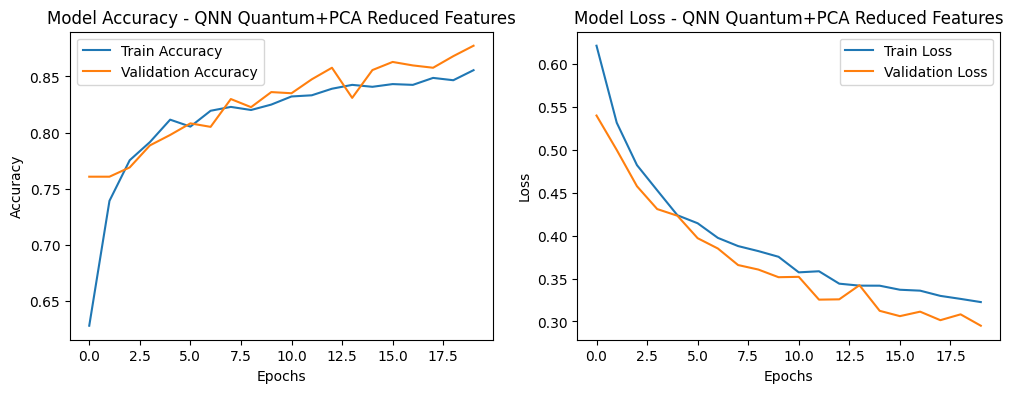

In [9]:
plot_history(history_transformer, "QNN Quantum+PCA Reduced Features")

In [10]:
# ✅ Evaluate
test_loss, test_acc = transformer_model.evaluate(X_test_seq, y_test)
print(f"QNN Test Accuracy: {test_acc:.4f} | Loss: {test_loss:.4f}")

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8711 - loss: 0.3007
QNN Test Accuracy: 0.8711 | Loss: 0.3007


31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step


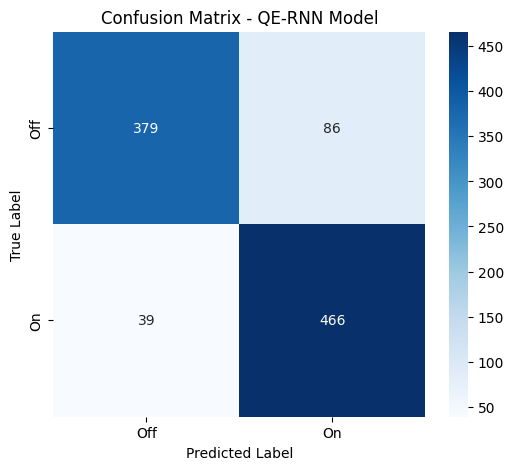

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.82      0.86       465
           1       0.84      0.92      0.88       505

    accuracy                           0.87       970
   macro avg       0.88      0.87      0.87       970
weighted avg       0.87      0.87      0.87       970



In [11]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 🔹 Step 1: Get prediction probabilities
y_pred_probs = transformer_model.predict(X_test)

# 🔹 Step 2: Binarize predictions (assuming sigmoid output layer)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

# 🔹 Step 3: Decode true labels if they're one-hot encoded
if len(y_test.shape) > 1 and y_test.shape[1] > 1:
    y_test = np.argmax(y_test, axis=1)  # convert [0,1] to 1 and [1,0] to 0

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt=".0f", cmap="Blues",
            xticklabels=["Off", "On"], yticklabels=["Off", "On"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - QE-RNN Model")
plt.show()

print("Classification Report:\n", classification_report(y_test, y_pred))

# Confidence Check

In [12]:
import numpy as np

# Get model predictions
y_pred_probs = transformer_model.predict(X_test)

# Check confidence distribution
print("Min Confidence:", np.min(y_pred_probs))
print("Max Confidence:", np.max(y_pred_probs))
print("Mean Confidence:", np.mean(y_pred_probs))

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Min Confidence: 0.03664258
Max Confidence: 0.99905473
Mean Confidence: 0.5584977


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


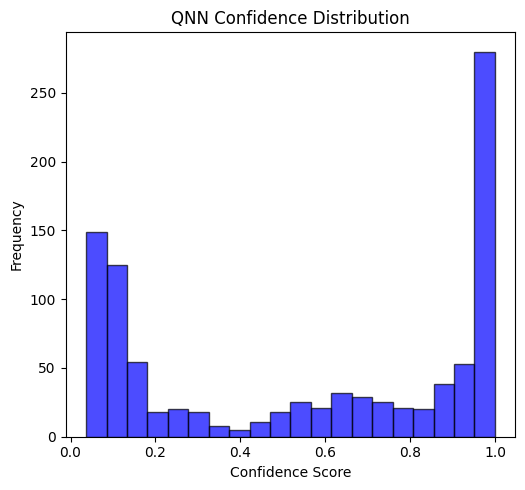

In [13]:
y_true_qnn = y_test# Convert one-hot labels to class labels
y_pred_qnn = np.argmax(transformer_model.predict(X_test), axis=1)
confidences_qnn = np.max(transformer_model.predict(X_test), axis=1)

# Convert to numpy arrays if needed
qnn_confidences = np.array(confidences_qnn)  # Replace with your QNN confidence list

plt.figure(figsize=(10, 5))

# QNN Confidence Distribution
plt.subplot(1, 2, 1)
plt.hist(qnn_confidences, bins=20, color='blue', alpha=0.7, edgecolor='black')
plt.title("QNN Confidence Distribution")
plt.xlabel("Confidence Score")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# K-Fold

In [17]:
import numpy as np
import tensorflow as tf
from sklearn.model_selection import KFold

# --- Ensure correct shape ---
X_seq = np.expand_dims(X_train, axis=-1)  # (samples, 10, 1)
print("Transformer input shape:", X_seq.shape)

# --- K-Fold setup ---
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

train_accs, val_accs, train_losses, val_losses = [], [], [], []

def build_transformer_baseline(input_shape, embed_dim=32, num_heads=4, ff_dim=64, dropout=0.2):
    inputs = tf.keras.Input(shape=input_shape)
    x = tf.keras.layers.Dense(embed_dim)(inputs)

    # --- Self-Attention block 1 ---
    attn_out = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(x, x)
    x = tf.keras.layers.Add()([x, attn_out])
    x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)

    ff = tf.keras.Sequential([
        tf.keras.layers.Dense(ff_dim, activation="relu"),
        tf.keras.layers.Dense(embed_dim),
    ])
    ff_out = ff(x)
    x = tf.keras.layers.Add()([x, ff_out])
    x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
    x = tf.keras.layers.Dropout(dropout)(x)

    # --- Self-Attention block 2 (light) ---
    attn_out = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(x, x)
    x = tf.keras.layers.Add()([x, attn_out])
    x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)

    ff_out = ff(x)
    x = tf.keras.layers.Add()([x, ff_out])
    x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
    x = tf.keras.layers.Dropout(dropout)(x)

    # --- Pool + classification head ---
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(32, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4, clipvalue=0.5),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# --- K-Fold training ---
for fold, (train_idx, val_idx) in enumerate(kf.split(X_seq)):
    print(f"\n🧠 Training Transformer Fold {fold+1}/{k}")

    X_train_fold, X_val_fold = X_seq[train_idx], X_seq[val_idx]
    y_train_fold, y_val_fold = y_train[train_idx], y_train[val_idx]

    model = build_transformer_baseline((X_seq.shape[1], 1))

    history = model.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=20, batch_size=32, verbose=1
    )

    # --- Record last-epoch stats ---
    train_accs.append(history.history['accuracy'])
    val_accs.append(history.history['val_accuracy'])
    train_losses.append(history.history['loss'])
    val_losses.append(history.history['val_loss'])

    val_eval = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    print(f"Fold {fold+1} Validation Accuracy: {val_eval[1]*100:.2f}%")

# --- Summarize ---
print("\n📊 Final K-Fold Results (Transformer Baseline):")
print(f"Train Accuracy: {np.mean(train_accs):.4f} ± {np.std(train_accs):.4f}")
print(f"Val Accuracy:   {np.mean(val_accs):.4f} ± {np.std(val_accs):.4f}")
print(f"Train Loss:     {np.mean(train_losses):.4f} ± {np.std(train_losses):.4f}")
print(f"Val Loss:       {np.mean(val_losses):.4f} ± {np.std(val_losses):.4f}")


Transformer input shape: (2908, 10, 1)

🧠 Training Transformer Fold 1/5
Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.5920 - loss: 0.6513 - val_accuracy: 0.8282 - val_loss: 0.5399
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.7064 - loss: 0.5545 - val_accuracy: 0.8247 - val_loss: 0.4814
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.7567 - loss: 0.5046 - val_accuracy: 0.8076 - val_loss: 0.4520
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.7820 - loss: 0.4793 - val_accuracy: 0.8282 - val_loss: 0.4144
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.7885 - loss: 0.4547 - val_accuracy: 0.8351 - val_loss: 0.3905
Epoch 6/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.7997 - loss: 0.4377 - val_accuracy: 0.8522 - val_loss: 0.3732
Epoch 7/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.7997 - loss: 0.4244 - val_accuracy: 0.8522 - val_loss: 0.3603
Epoch 8/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 2


Final Transformer K-Fold Validation Accuracy: 0.8304


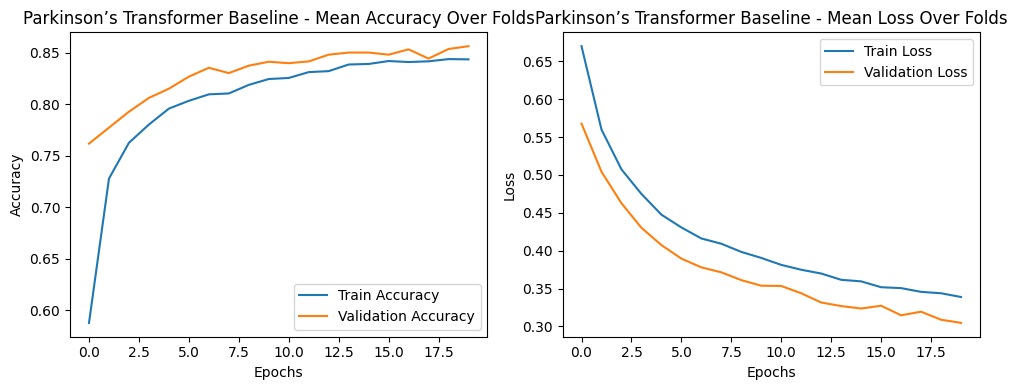

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# --- Convert lists to arrays ---
train_accs = np.array(train_accs)
val_accs = np.array(val_accs)
train_losses = np.array(train_losses)
val_losses = np.array(val_losses)

# --- Compute mean across folds (per epoch) ---
mean_train_acc = np.mean(train_accs, axis=0)
mean_val_acc = np.mean(val_accs, axis=0)
mean_train_loss = np.mean(train_losses, axis=0)
mean_val_loss = np.mean(val_losses, axis=0)

# --- Final mean accuracy (last epoch) ---
final_accuracy = np.mean(val_accs)
print(f"\nFinal Transformer K-Fold Validation Accuracy: {final_accuracy:.4f}")

# --- Plotting ---
plt.figure(figsize=(10, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(mean_train_acc, label='Train Accuracy')
plt.plot(mean_val_acc, label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Parkinson’s Transformer Baseline - Mean Accuracy Over Folds")
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(mean_train_loss, label='Train Loss')
plt.plot(mean_val_loss, label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Parkinson’s Transformer Baseline - Mean Loss Over Folds")
plt.legend()

plt.tight_layout()
plt.show()

In [20]:
import pandas as pd
import numpy as np

# Convert lists to numpy arrays
folds = list(range(1, len(train_accs) + 1))

# Create DataFrame with results per fold
df_results = pd.DataFrame({
    'Fold': folds,
    'Final Train Accuracy': [train_acc[-1] for train_acc in train_accs],
    'Final Validation Accuracy': [val_acc[-1] for val_acc in val_accs],
    'Final Train Loss': [train_loss[-1] for train_loss in train_losses],
    'Final Validation Loss': [val_loss[-1] for val_loss in val_losses]
})

# Print results
print("\n📊 K-Fold Cross-Validation Results:\n")
print(df_results)

# Compute summary statistics (mean & std deviation)
df_summary = df_results.describe().loc[['mean', 'std']]
print("\n📌 Summary Statistics (Mean & Std Deviation):\n")
print(df_summary)


📊 K-Fold Cross-Validation Results:

   Fold  Final Train Accuracy  Final Validation Accuracy  Final Train Loss  \
0     1              0.839639                   0.872852          0.348604   
1     2              0.852107                   0.848797          0.324585   
2     3              0.840069                   0.835052          0.337292   
3     4              0.850021                   0.862306          0.344712   
4     5              0.835410                   0.862306          0.338858   

   Final Validation Loss  
0               0.292412  
1               0.309898  
2               0.328181  
3               0.295081  
4               0.297543  

📌 Summary Statistics (Mean & Std Deviation):

          Fold  Final Train Accuracy  Final Validation Accuracy  \
mean  3.000000              0.843449                   0.856263   
std   1.581139              0.007223                   0.014611   

      Final Train Loss  Final Validation Loss  
mean          0.338810             